In [13]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Make the plots look nice
sns.set_theme(style="whitegrid")

In [14]:
# Point this to your specific directory
directory_path = "runs/qwen35_9b_robot/eval_results/"
json_files = [
    f for f in glob.glob(os.path.join(directory_path, "*.json")) 
    if os.path.basename(f) != "all_metrics.json"
]

data = []

for file_path in json_files:
    filename = os.path.basename(file_path)
    
    if "base" in filename:
        step = 0
    elif "final" in filename:
        step = 99999 
    else:
        try:
            step = int(filename.split("-")[1].split(".")[0])
        except:
            step = -1

    with open(file_path, 'r', encoding='utf-8') as f:
        content = json.load(f)
        
    metrics = content.get("metrics", {})
    per_field_acc = metrics.get("per_field_accuracy", {})
    per_field_metrics = metrics.get("per_field_metrics", {})
    hazard_binary = metrics.get("hazard_present_binary", {})
    
    # Helper to safely get macro_f1
    def get_f1(field):
        return per_field_metrics.get(field, {}).get("macro_f1", 0)
    
    # Helper to sum False Positives across all classes in a field
    def get_fp(field):
        labels = per_field_metrics.get(field, {}).get("labels", {})
        return sum(label_info.get("fp", 0) for label_info in labels.values())

    row = {
        "checkpoint": filename.replace(".json", ""),
        "step": step,
        
        # --- OVERALL METRICS ---
        "exact_match_accuracy": metrics.get("exact_match_accuracy", 0),
        "hazard_f1": hazard_binary.get("f1", 0),
        "hazard_recall": hazard_binary.get("recall", 0), 
        "samples_per_sec": metrics.get("samples_per_sec", 0),
        
        # --- PER-FIELD ACCURACY ---
        "hazard_label_acc": per_field_acc.get("hazard_label", 0),
        "hazard_present_acc": per_field_acc.get("hazard_present", 0),
        "zone_relation_acc": per_field_acc.get("zone_relation", 0),
        "object_state_acc": per_field_acc.get("object_state", 0),
        "object_direction_acc": per_field_acc.get("object_direction", 0),
        
        # --- PER-FIELD MACRO F1 ---
        "hazard_label_f1": get_f1("hazard_label"),
        "hazard_present_f1": get_f1("hazard_present"),
        "zone_relation_f1": get_f1("zone_relation"),
        "object_state_f1": get_f1("object_state"),
        "object_direction_f1": get_f1("object_direction"),
        
        # --- PER-FIELD FALSE POSITIVES ---
        "hazard_label_fp": get_fp("hazard_label"),
        "hazard_present_fp": get_fp("hazard_present"),
        "zone_relation_fp": get_fp("zone_relation"),
        "object_state_fp": get_fp("object_state"),
        "object_direction_fp": get_fp("object_direction")
    }
    data.append(row)

# Create DataFrame and sort it chronologically
df = pd.DataFrame(data)
df = df.sort_values("step").reset_index(drop=True)

# Preview the first few rows
df.head()

,checkpoint,step,exact_match_accuracy,hazard_f1,hazard_recall,samples_per_sec,hazard_label_acc,hazard_present_acc,zone_relation_acc,object_state_acc,...,hazard_label_f1,hazard_present_f1,zone_relation_f1,object_state_f1,object_direction_f1,hazard_label_fp,hazard_present_fp,zone_relation_fp,object_state_fp,object_direction_fp
0,base_pretrained,0,0.0068,0.0000,0.0,0.1828,0.0477,0.0477,0.0295,0.1909,...,0.0456,0.0456,0.0287,0.1647,1.0,419,419,427,356,0
1,checkpoint-85,85,0.9523,0.9756,1.0,0.2030,0.9523,0.9523,0.9705,0.9750,...,0.4878,0.4878,0.4925,0.4937,1.0,21,21,13,11,0
2,checkpoint-170,170,0.9659,0.9824,1.0,0.2029,0.9659,0.9659,0.9705,0.9886,...,0.7134,0.7134,0.4925,0.8500,1.0,15,15,13,5,0
3,checkpoint-255,255,0.9659,0.9824,1.0,0.1989,0.9659,0.9659,0.9705,0.9886,...,0.7134,0.7134,0.4925,0.8500,1.0,15,15,13,5,0
4,checkpoint-340,340,0.9659,0.9824,1.0,0.2059,0.9659,0.9659,0.9705,0.9886,...,0.7134,0.7134,0.4925,0.8500,1.0,15,15,13,5,0


0 [-0.40353125 -0.9137578 ]
9 [-0.00762256  0.20697336]
1 [0.51569273 0.56523665]
10 [-0.85826227  0.12681561]
2 [0.94793511 0.16069908]
11 [-0.76703089  0.75766101]
3 [-0.37651037  0.46820259]
12 [0.08236119 0.57075931]
4 [0.48541177 0.06309009]
13 [ 0.94147436 -0.62556741]
5 [0.90521667 0.43503817]
14 [ 0.62526952 -0.84240869]
6 [-0.4730174   0.29503664]
15 [-0.23764666 -0.94028176]
7 [ 0.63001552 -0.55722816]
16 [0.09622311 0.28942224]
8 [0.57758855 0.70747643]
17 [-0.16662093  0.22624954]


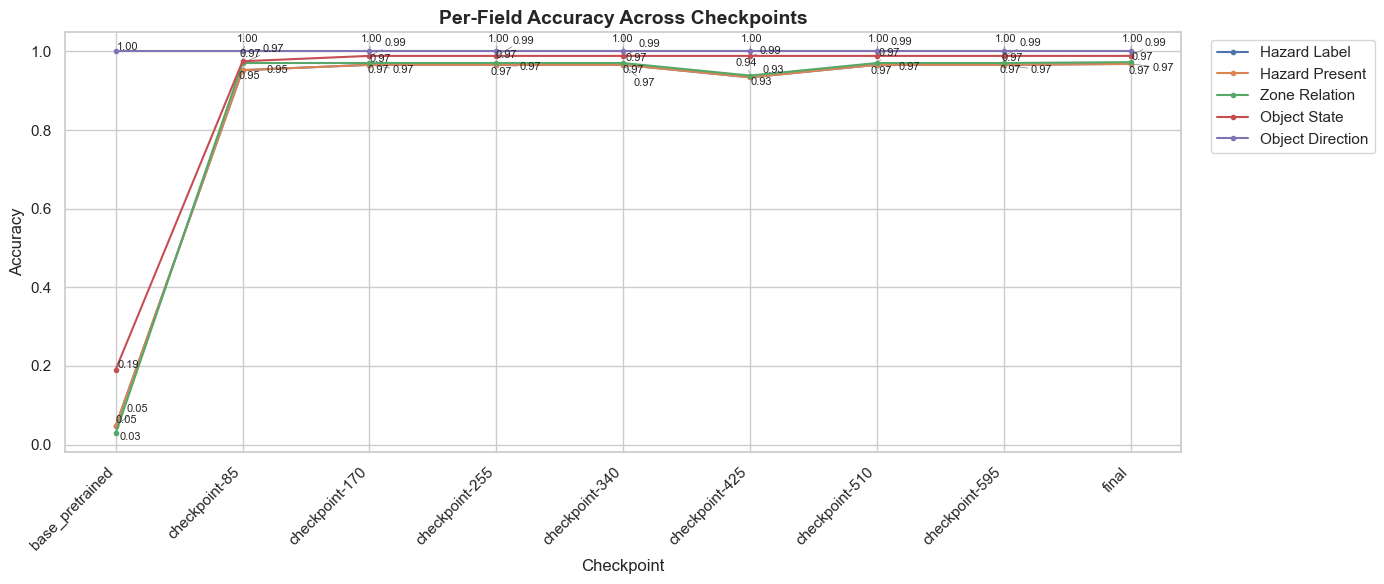

In [15]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

# ... (assuming df is defined above this snippet) ...

fields_to_plot = [
    "hazard_label_acc", 
    "hazard_present_acc", 
    "zone_relation_acc", 
    "object_state_acc", 
    "object_direction_acc"
]

plt.figure(figsize=(14, 6))

# 1. Create an empty list to store the text objects
texts = []

for field in fields_to_plot:
    # Remove the "_acc" for a cleaner legend label
    clean_label = field.replace("_acc", "").replace("_", " ").title()
    plt.plot(df["checkpoint"], df[field], marker='.', label=clean_label, linewidth=1.5)
    
    for x, y in zip(df["checkpoint"], df[field]):
        # 2. Append the text object to the list (removed ha and va since adjust_text handles positioning)
        texts.append(plt.text(x, y, f'{y:.2f}', fontsize=8))

# 3. Call adjust_text on the list of text objects
# arrowprops draws a small line from the text to the point if it gets moved far away
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.title("Per-Field Accuracy Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Put the legend outside the chart so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()

0 [-0.21838876  0.89376038]
9 [0.6394184  0.49519462]
1 [0.66722794 0.89947598]
10 [-0.84835806  0.31961979]
2 [-0.93355158 -0.76770092]
11 [0.68881253 0.2112105 ]
3 [-0.37654107  0.32934362]
12 [-0.92957115  0.29247336]
4 [-0.72889278  0.76964508]
13 [-0.82655268 -0.77395134]
5 [ 0.57826626 -0.03858762]
14 [ 0.58459258 -0.14951299]
6 [-0.38837767 -0.48640855]
15 [ 0.77298197 -0.46167112]
7 [ 0.83868386 -0.30407834]
16 [-0.88206093 -0.30659055]
8 [ 0.138041   -0.43210094]
17 [-0.96503553  0.59941674]


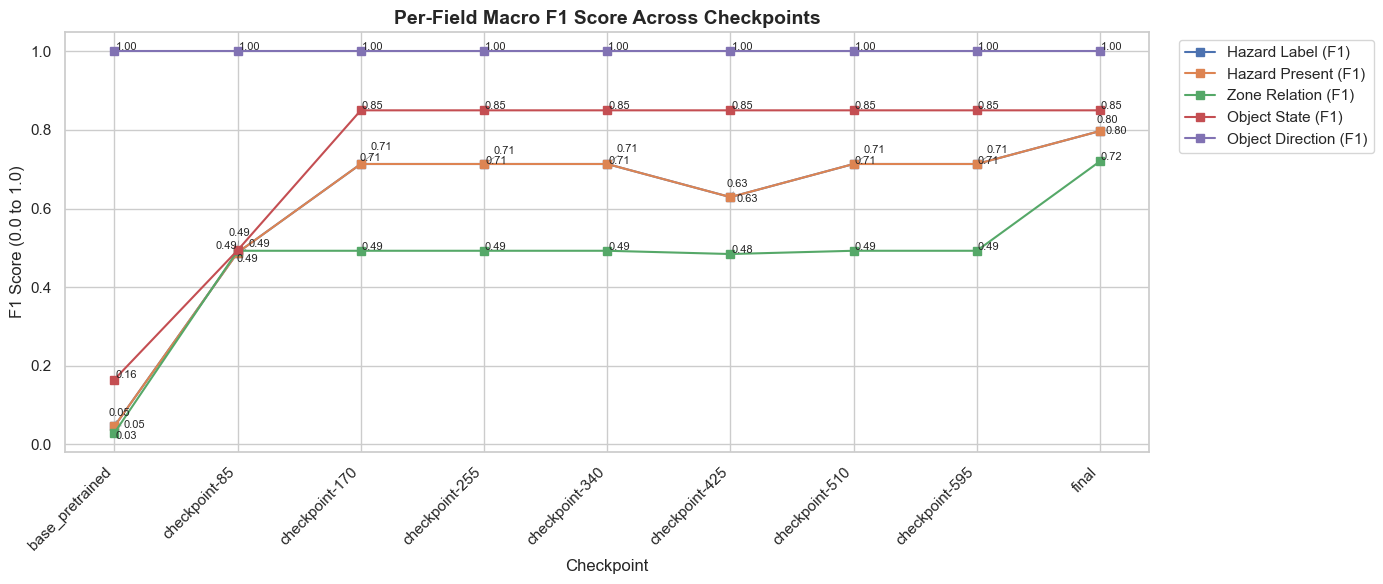

In [16]:
fields_to_plot_f1 = [
    "hazard_label_f1", 
    "hazard_present_f1", 
    "zone_relation_f1", 
    "object_state_f1", 
    "object_direction_f1"
]

plt.figure(figsize=(14, 6))

texts = [] # List to collect all the text objects

for field in fields_to_plot_f1:
    clean_label = field.replace("_f1", "").replace("_", " ").title() + " (F1)"
    plt.plot(df["checkpoint"], df[field], marker='s', label=clean_label, linewidth=1.5)
    
    # Create the text objects but don't finalize their positions yet
    for x, y in zip(df["checkpoint"], df[field]):
        texts.append(plt.text(x, y, f'{y:.2f}', fontsize=8))

# Let adjustText do the heavy lifting to prevent overlaps
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title("Per-Field Macro F1 Score Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("F1 Score (0.0 to 1.0)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()

0 [-0.26358473 -0.13011169]
9 [-0.85265274 -0.10393218]
1 [0.79586367 0.83920444]
10 [-0.65862569 -0.71780648]
2 [-0.10535621  0.00192005]
11 [ 0.17325092 -0.75615869]
3 [-0.60270763 -0.05074257]
12 [-0.41903721 -0.85305923]
4 [0.45637259 0.71178146]
13 [-0.07113741  0.75890562]
5 [-0.07345476 -0.39886998]
14 [-0.63851633 -0.05067319]
6 [0.12538313 0.55686587]
15 [-0.5723764 -0.7506275]
7 [-0.61748422  0.252917  ]
16 [-0.43171417  0.36480884]
8 [-0.45538628 -0.11587257]
17 [-0.42362434 -0.10577608]


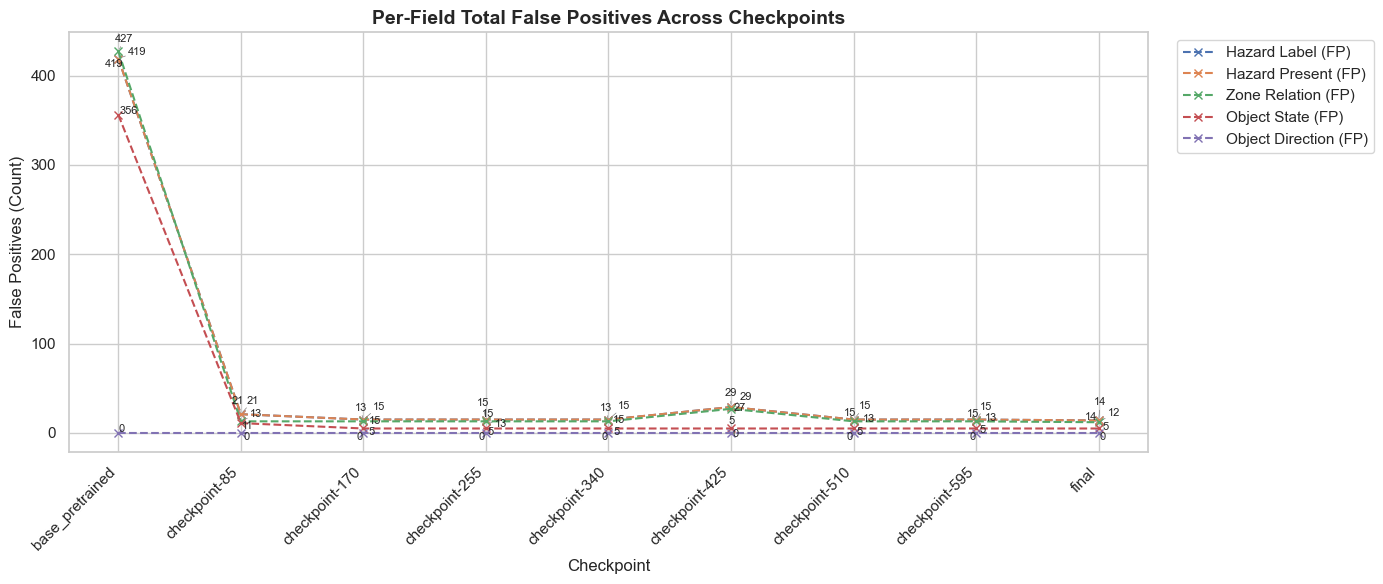

In [17]:
fields_to_plot_fp = [
    "hazard_label_fp", 
    "hazard_present_fp", 
    "zone_relation_fp", 
    "object_state_fp", 
    "object_direction_fp"
]

plt.figure(figsize=(14, 6))
texts = [] # List to collect text objects for automatic adjustment

for field in fields_to_plot_fp:
    # Formatting label for the legend
    clean_label = field.replace("_fp", "").replace("_", " ").title() + " (FP)"
    
    # Plotting with 'x' markers and dashed lines as requested
    plt.plot(df["checkpoint"], df[field], marker='x', label=clean_label, linewidth=1.5, linestyle='--')
    
    # Adding data labels to the list
    for x, y in zip(df["checkpoint"], df[field]):
        # Using int(y) for clean count labels
        texts.append(plt.text(x, y, f'{int(y)}', fontsize=8))

# This handles the magic of moving overlapping numbers
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title("Per-Field Total False Positives Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("False Positives (Count)", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Place legend outside to the right
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()

In [18]:
import json

# Path to your evaluation JSON
file_path = "runs/qwen35_9b_lora_newprompt/eval_results/checkpoint-648.json"

def debug_mismatches_with_video(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = data.get("per_sample", [])
    
    # Updated headers to include Source Video ID
    print(f"{'Field':<18} | {'GT':<12} | {'Pred':<12} | {'Source Video ID':<45} | {'Sample ID'}")
    print("-" * 140)

    mismatch_count = 0

    for sample in samples:
        gt = sample.get("ground_truth", {})
        pred = sample.get("prediction_parsed", {})
        matches = sample.get("field_matches", {})
        
        # Pulling source_video_id from the 'meta' dictionary
        meta = sample.get("meta", {})
        video_id = meta.get("source_video_id", "N/A")
        sample_id = sample.get("sample_id", "Unknown")

        # Check every field for a False match
        for field, is_match in matches.items():
            if is_match is False:
                gt_val = gt.get(field, "N/A")
                pred_val = pred.get(field, "N/A")
                
                # Print the mismatch with the Video ID
                print(f"{field:<18} | {str(gt_val):<12} | {str(pred_val):<12} | {str(video_id):<45} | {sample_id}")
                mismatch_count += 1

    print("-" * 140)
    print(f"Total Mismatches Found: {mismatch_count}")

debug_mismatches_with_video(file_path)

Field              | GT           | Pred         | Source Video ID                               | Sample ID
--------------------------------------------------------------------------------------------------------------------------------------------
hazard_label       | unsafe_forklift_approach | no_hazard    | 동일유리02_S20250716113905_E20250716114050        | 동일유리02_S20250716113905_E20250716114050__000065000_000070000
hazard_present     | yes          | no           | 동일유리02_S20250716113905_E20250716114050        | 동일유리02_S20250716113905_E20250716114050__000065000_000070000
object_direction   | towards      | away         | 동일유리02_S20250716113905_E20250716114050        | 동일유리02_S20250716113905_E20250716114050__000065000_000070000
hazard_label       | unsafe_forklift_approach | no_hazard    | 금진Camera05_S20251213082156_E20251213083037    | 금진Camera05_S20251213082156_E20251213083037__000004000_000009000
hazard_present     | yes          | no           | 금진Camera05_S20251213082156_E2025121